In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

df = pd.read_csv('lstm_agnostic_cycles_data.csv')

features = ['hour_of_day', 'is_weekend', 'minutes_since_empty', 'fill_level_percent']
target = 'fill_level_percent'

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

df_scaled = df.copy()
df_scaled[features] = scaler_X.fit_transform(df[features])

scaler_y.fit(df[[target]])

def create_sequences(data, seq_length):
    X, y = [], []
    for cycle, group in data.groupby('cycle_id'):
        group_X = group[features].values
        group_y = group[target].values

        if len(group) > seq_length:
            for i in range(len(group) - seq_length):
                X.append(group_X[i : i + seq_length])
                y.append(group_y[i + seq_length])

    return np.array(X), np.array(y)

SEQ_LENGTH = 12
X, y = create_sequences(df_scaled, SEQ_LENGTH)

print(f"Bentuk Input X: {X.shape} -> (Jumlah Sampel, Seq Length, Jumlah Fitur)")
print(f"Bentuk Target y: {y.shape}")

split_idx = int(0.8 * len(X))

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Jumlah sampel training: {len(X_train)}")
print(f"Jumlah sampel testing: {len(X_test)}")

Bentuk Input X: (56946, 12, 4) -> (Jumlah Sampel, Seq Length, Jumlah Fitur)
Bentuk Target y: (56946,)
Jumlah sampel training: 45556
Jumlah sampel testing: 11390


=== 1. INFORMASI DASAR DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62946 entries, 0 to 62945
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   cycle_id             62946 non-null  int64         
 1   timestamp            62946 non-null  datetime64[ns]
 2   hour_of_day          62946 non-null  int64         
 3   is_weekend           62946 non-null  int64         
 4   minutes_since_empty  62946 non-null  int64         
 5   fill_level_percent   62946 non-null  float64       
 6   pickup_event         62946 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(5)
memory usage: 3.4 MB
None

=== 2. STATISTIK DESKRIPTIF ===
           cycle_id            timestamp   hour_of_day    is_weekend  \
count  62946.000000                62946  62946.000000  62946.000000   
mean     256.763829  2025-11-24 20:07:30     11.496076      0.286245   
min        1.000000  

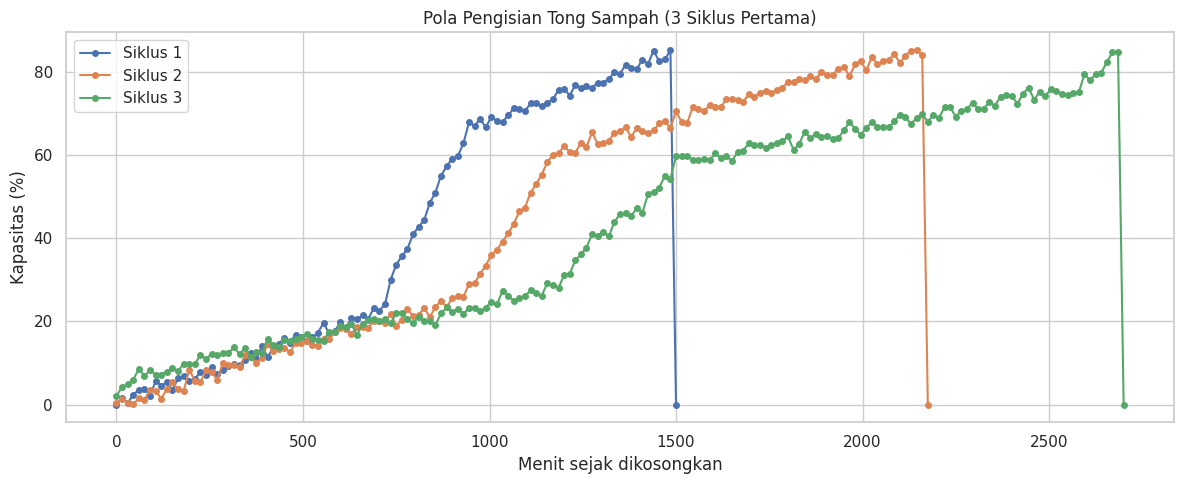

In [ ]:
import seaborn as sns

df['timestamp'] = pd.to_datetime(df['timestamp'])

print("=== 1. INFORMASI DASAR DATASET ===")
print(df.info())
print("\n=== 2. STATISTIK DESKRIPTIF ===")
print(df.describe())

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 5))
for cycle in [1, 2, 3]:
    subset = df[df['cycle_id'] == cycle]
    plt.plot(subset['minutes_since_empty'], subset['fill_level_percent'],
             marker='o', markersize=4, label=f'Siklus {cycle}')

plt.title('Pola Pengisian Tong Sampah (3 Siklus Pertama)')
plt.xlabel('Menit sejak dikosongkan')
plt.ylabel('Kapasitas (%)')
plt.legend()
plt.tight_layout()
plt.show()

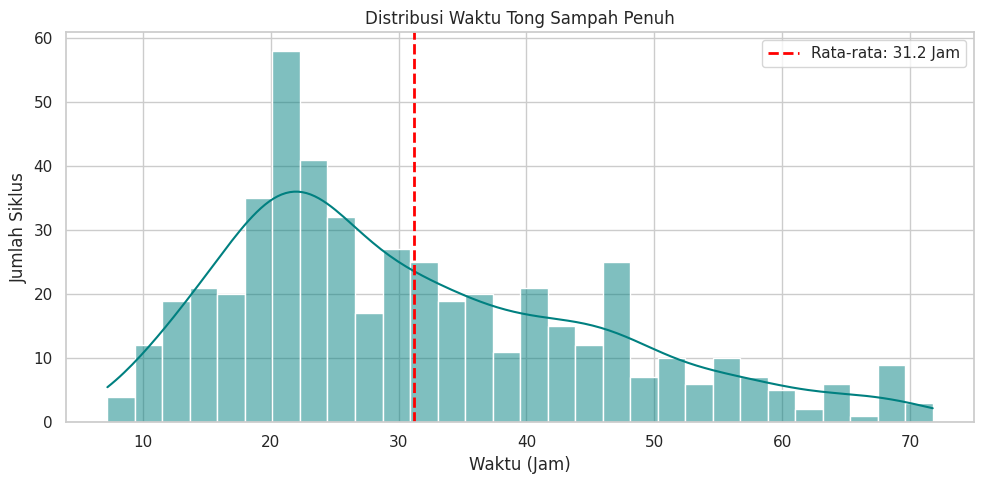

In [ ]:
plt.figure(figsize=(10, 5))
cycle_durations = df.groupby('cycle_id')['minutes_since_empty'].max() / 60 # ubah ke jam

sns.histplot(cycle_durations, bins=30, kde=True, color='teal')
plt.title('Distribusi Waktu Tong Sampah Penuh')
plt.xlabel('Waktu (Jam)')
plt.ylabel('Jumlah Siklus')
plt.axvline(cycle_durations.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Rata-rata: {cycle_durations.mean():.1f} Jam')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_5122/2367105273.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_rate.index, y=hourly_rate.values, palette='viridis')


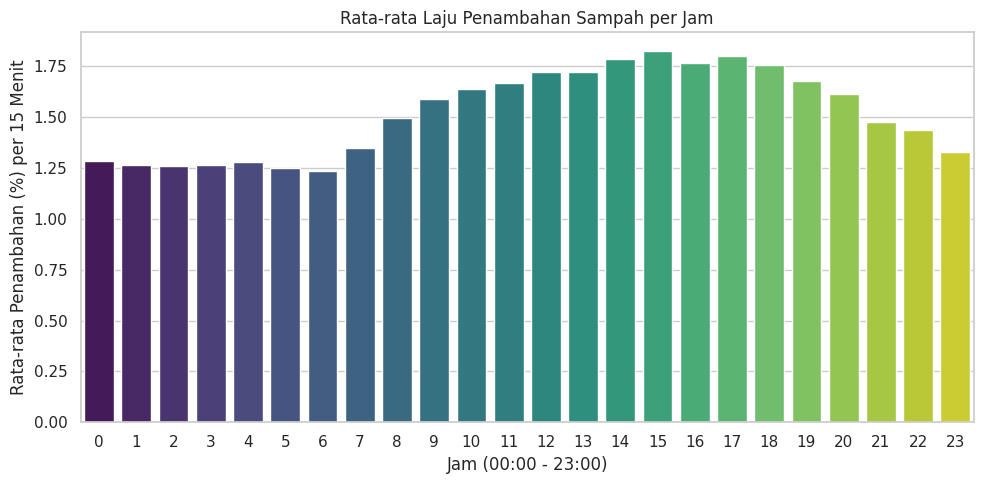

In [ ]:
plt.figure(figsize=(10, 5))
df['fill_rate'] = df.groupby('cycle_id')['fill_level_percent'].diff().fillna(0)
laju_positif = df[df['fill_rate'] >= 0]

hourly_rate = laju_positif.groupby('hour_of_day')['fill_rate'].mean()
sns.barplot(x=hourly_rate.index, y=hourly_rate.values, palette='viridis')
plt.title('Rata-rata Laju Penambahan Sampah per Jam')
plt.xlabel('Jam (00:00 - 23:00)')
plt.ylabel('Rata-rata Penambahan (%) per 15 Menit')
plt.tight_layout()
plt.show()

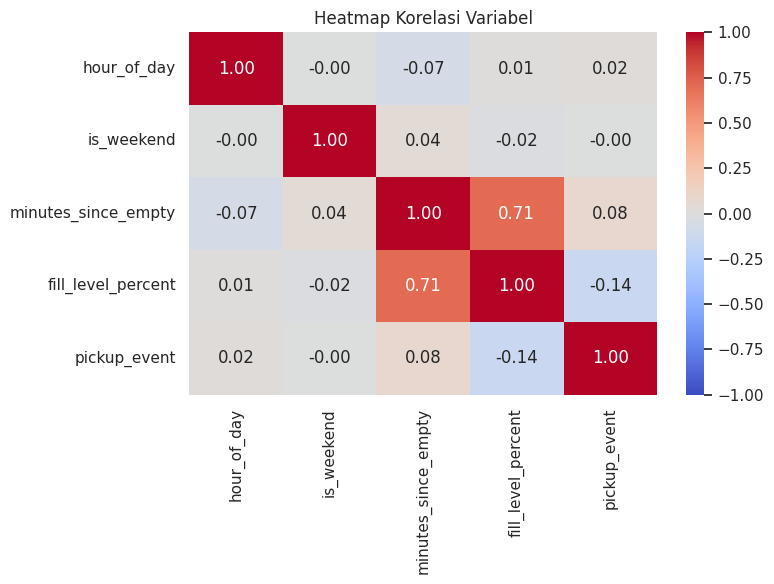

In [ ]:
plt.figure(figsize=(8, 6))
fitur_numerik = ['hour_of_day', 'is_weekend', 'minutes_since_empty', 'fill_level_percent', 'pickup_event']
korelasi = df[fitur_numerik].corr()

sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Variabel')
plt.tight_layout()
plt.show()

In [ ]:
model = Sequential()

model.add(LSTM(units=64, return_sequences=True, input_shape=(SEQ_LENGTH, len(features))))
model.add(Dropout(0.2))

model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

print("\nMemulai proses pelatihan model...")
history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)


Memulai proses pelatihan model...
Epoch 1/25
641/641 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 0.0166 - val_loss: 0.0086
Epoch 2/25
641/641 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 0.0112 - val_loss: 0.0081
Epoch 3/25
641/641 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - loss: 0.0102 - val_loss: 0.0087
Epoch 4/25
641/641 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - loss: 0.0096 - val_loss: 0.0079
Epoch 5/25
641/641 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - loss: 0.0090 - val_loss: 0.0078
Epoch 6/25
641/641 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - loss: 0.0087 - val_loss: 0.0075
Epoch 7/25
641/641 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 0.0085 - val_loss: 0.0074
Epoch 8/25
641/641 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0083 - val_loss: 0.0074
Epoch 9/25
641/641 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - loss: 0.0082 - val_loss: 0.0074
Epoch 10/25
641/641 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - loss: 0.0083 - val_loss: 0.0073
Epoch 11/25
641/641 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - loss: 0.0082 - val_loss: 0.

In [ ]:
import joblib

nama_model = 'lstm_waste_model.h5'
model.save(nama_model)
print(f"✅ Model LSTM berhasil disimpan sebagai: {nama_model}")

nama_scaler_x = 'scaler_X.pkl'
nama_scaler_y = 'scaler_y.pkl'

joblib.dump(scaler_X, nama_scaler_x)
joblib.dump(scaler_y, nama_scaler_y)

print(f"✅ Scaler X berhasil disimpan sebagai: {nama_scaler_x}")
print(f"✅ Scaler Y berhasil disimpan sebagai: {nama_scaler_y}")

from google.colab import files
files.download(nama_model)
files.download(nama_scaler_x)
files.download(nama_scaler_y)

✅ Model LSTM berhasil disimpan sebagai: lstm_waste_model.h5
✅ Scaler X berhasil disimpan sebagai: scaler_X.pkl
✅ Scaler Y berhasil disimpan sebagai: scaler_y.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd
import joblib
from tensorflow.keras.models import load_model

print("Memuat model dan scaler...")
deployed_model = load_model('lstm_waste_model.h5')
deployed_scaler_X = joblib.load('scaler_X.pkl')
deployed_scaler_y = joblib.load('scaler_y.pkl')

data_sensor_baru = [
    [8, 0, 15, 5.0],
    [8, 0, 30, 6.2],
    [8, 0, 45, 7.5],
    [9, 0, 60, 9.0],
    [9, 0, 75, 10.5],
    [9, 0, 90, 12.0],
    [9, 0, 105, 14.1],
    [10, 0, 120, 16.5],
    [10, 0, 135, 19.0],
    [10, 0, 150, 22.5],
    [10, 0, 165, 25.0],
    [11, 0, 180, 28.5]
]

nama_fitur = ['hour_of_day', 'is_weekend', 'minutes_since_empty', 'fill_level_percent']
df_sensor_baru = pd.DataFrame(data_sensor_baru, columns=nama_fitur)

data_scaled = deployed_scaler_X.transform(df_sensor_baru)

X_inference = data_scaled.reshape(1, 12, 4)

prediksi_scaled = deployed_model.predict(X_inference)

prediksi_asli = deployed_scaler_y.inverse_transform(prediksi_scaled)

print(f"\nPrediksi Kapasitas 15 menit ke depan (Menit ke-195): {prediksi_asli[0][0]:.2f}%")

Memuat model dan scaler...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step

Prediksi Kapasitas 15 menit ke depan (Menit ke-195): 29.24%
